## Pandas analysis

This exercise consists in analyzing a dataset containg timing information from a series of Time-to-Digital-Converters (TDC) implemented in a couple of FPGAs. Each measurement (i.e. each row of the input file) consists of a flag that specifies the type of message ('HEAD', which in this case is always 1), two addresses of the TDC providing the signal ('FPGA' and 'TDC_CHANNEL'), and the timing information ('ORBIT_CNT', 'BX_COUNTER', and 'TDC_MEAS'). Each TDC count corresponds to 25/30 ns, whereas a unit of BX_COUNTER corresponds to 25 ns, and the ORBIT_CNT is increased every 'x' BX_COUNTER. This allows to store the time in a similar way to hours, minutes and seconds.

In [1]:
# If you didn't download it yet, please get the relevant file now!
!wget https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt -P ~/data/

--2025-11-27 09:10:33--  https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6025:18::a27d:4512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/pkkpoxlm7beasryexpdf8/data_000637.txt?rlkey=rkm2em1v57hewglzelmin21c9 [following]
--2025-11-27 09:10:33--  https://www.dropbox.com/scl/fi/pkkpoxlm7beasryexpdf8/data_000637.txt?rlkey=rkm2em1v57hewglzelmin21c9
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc3c7897d5f2331a5e873295d4e4.dl.dropboxusercontent.com/cd/0/inline/C1_SPFSZGBUdzewyWFGq8MqDK63BsbpT9FU5h7mmmB7H-2rYmADuB2Hr37mxvuEXGR4kLXD4fdPyh0z7_M9LPK2ar92jbQUxfH5RfPa_COEdmOii7nLTO5ug_fxQaGpv-Hg/file# [following]
--2025-11-27 09:10:34--  https://uc3c7897d5f2331a5e873295d4e4.dl.dropboxusercontent.com/cd/0/inline/C1_SPFSZGB

In [1]:
!wget https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt

--2026-02-05 09:36:13--  https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt
Resolving www.dropbox.com (www.dropbox.com)... 162.125.69.18, 2620:100:6025:18::a27d:4512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.69.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/pkkpoxlm7beasryexpdf8/data_000637.txt?rlkey=rkm2em1v57hewglzelmin21c9 [following]
--2026-02-05 09:36:14--  https://www.dropbox.com/scl/fi/pkkpoxlm7beasryexpdf8/data_000637.txt?rlkey=rkm2em1v57hewglzelmin21c9
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc5c727c04ceb7b9be87eadb3aa3.dl.dropboxusercontent.com/cd/0/inline/C6UU89wVYstcYsmQqcDxdf7Mq4QLfGGHHhluaYgzIsK_I_TxU3IrYd3xg2cyp-vg3JSRijjeBzmWpJYFJwTlbW4oSo2I-STmS9PVkhMCNC7N_YkG_3O9Xeu_Id868gqReV8/file# [following]
--2026-02-05 09:36:15--  https://uc5c727c04ceb7b9be87eadb3aa3.dl.dropboxusercontent.com/cd/0/inline/C6UU89wVYs

Max row:  1310720


,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS
10001,1,0,47,3869200267,785,14
10002,1,0,63,3869200267,921,28
10003,1,0,64,3869200267,924,15
10004,1,0,7,3869200267,998,22
10005,1,0,8,3869200267,998,12
...,...,...,...,...,...,...
999995,1,0,62,3869209011,2560,29
999996,1,0,51,3869209011,2561,12
999997,1,0,61,3869209011,2562,2
999998,1,0,50,3869209011,2563,4


x =  3564


/tmp/ipykernel_375/1811196978.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_reduced['times'] = data_reduced['TDC_MEAS']*25/30 + data_reduced['BX_COUNTER']*30 + data_reduced['ORBIT_CNT']*(m+1)*30


,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,times
10001,1,0,47,3869200267,785,14,4.136949e+14
10002,1,0,63,3869200267,921,28,4.136949e+14
10003,1,0,64,3869200267,924,15,4.136949e+14
10004,1,0,7,3869200267,998,22,4.136949e+14
10005,1,0,8,3869200267,998,12,4.136949e+14
...,...,...,...,...,...,...,...
999995,1,0,62,3869209011,2560,29,4.136958e+14
999996,1,0,51,3869209011,2561,12,4.136958e+14
999997,1,0,61,3869209011,2562,2,4.136958e+14
999998,1,0,50,3869209011,2563,4,4.136958e+14


Elapse time=  0.9349655791250001  s


,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,times
10001,0,0,47,3869200267,785,14,4.136949e+14
10002,0,0,63,3869200267,921,28,4.136949e+14
10003,0,0,64,3869200267,924,15,4.136949e+14
10004,1,0,7,3869200267,998,22,4.136949e+14
10005,0,0,8,3869200267,998,12,4.136949e+14
...,...,...,...,...,...,...,...
999995,0,0,62,3869209011,2560,29,4.136958e+14
999996,1,0,51,3869209011,2561,12,4.136958e+14
999997,0,0,61,3869209011,2562,2,4.136958e+14
999998,1,0,50,3869209011,2563,4,4.136958e+14


,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,times
10004,1,0,7,3869200267,998,22,4.136949e+14
10006,1,0,10,3869200267,1009,10,4.136949e+14
10008,1,0,61,3869200267,1043,29,4.136949e+14
10011,1,0,50,3869200267,1385,8,4.136949e+14
10013,1,0,59,3869200267,1384,20,4.136949e+14
...,...,...,...,...,...,...,...
999989,1,1,4,3869209011,2551,14,4.136958e+14
999993,1,0,123,3869209011,2553,13,4.136958e+14
999996,1,0,51,3869209011,2561,12,4.136958e+14
999998,1,0,50,3869209011,2563,4,4.136958e+14


TDC_CHANNEL
1      11214
2      12995
3       8985
4      10778
5       6228
       ...  
129       13
130       28
137       31
138       27
139    41049
Name: count, Length: 133, dtype: int64

TDC_CHANNEL
1      11100
2      12823
3       8695
4      10892
5       6104
       ...  
129       15
130       25
137       19
138       25
139    40768
Name: count, Length: 133, dtype: int64

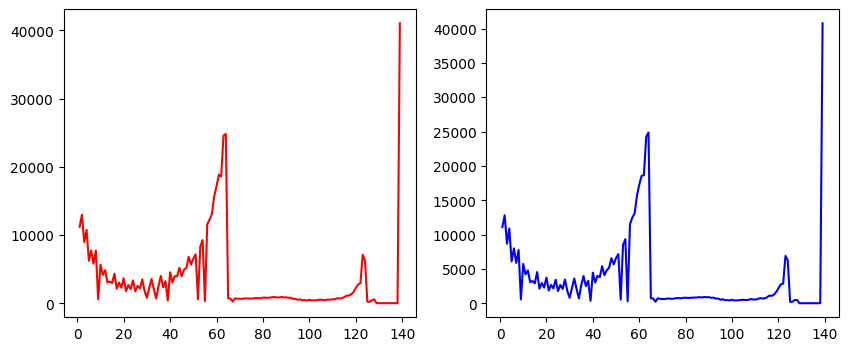

,HEAD,FPGA,ORBIT_CNT,BX_COUNTER,TDC_MEAS,times
TDC_CHANNEL,,,,,,
139,41049,41049,41049,41049,41049,41049
64,24835,24835,24835,24835,24835,24835
63,24584,24584,24584,24584,24584,24584
61,18854,18854,18854,18854,18854,18854
62,18587,18587,18587,18587,18587,18587
...,...,...,...,...,...,...
126,225,225,225,225,225,225
137,31,31,31,31,31,31
130,28,28,28,28,28,28


,HEAD,FPGA,ORBIT_CNT,BX_COUNTER,TDC_MEAS,times
TDC_CHANNEL,,,,,,
61,18854,18854,18854,18854,18854,18854
62,18587,18587,18587,18587,18587,18587
60,17181,17181,17181,17181,17181,17181
59,15703,15703,15703,15703,15703,15703
58,13072,13072,13072,13072,13072,13072
...,...,...,...,...,...,...
126,225,225,225,225,225,225
137,31,31,31,31,31,31
130,28,28,28,28,28,28


,HEAD,FPGA,ORBIT_CNT,BX_COUNTER,TDC_MEAS,times
TDC_CHANNEL,,,,,,
139,40768,40768,40768,40768,40768,40768
64,24875,24875,24875,24875,24875,24875
63,24252,24252,24252,24252,24252,24252
62,18655,18655,18655,18655,18655,18655
61,18555,18555,18555,18555,18555,18555
...,...,...,...,...,...,...
125,221,221,221,221,221,221
130,25,25,25,25,25,25
138,25,25,25,25,25,25


,HEAD,FPGA,ORBIT_CNT,BX_COUNTER,TDC_MEAS,times
TDC_CHANNEL,,,,,,
62,18655,18655,18655,18655,18655,18655
61,18555,18555,18555,18555,18555,18555
60,17264,17264,17264,17264,17264,17264
59,15663,15663,15663,15663,15663,15663
58,13080,13080,13080,13080,13080,13080
...,...,...,...,...,...,...
125,221,221,221,221,221,221
130,25,25,25,25,25,25
138,25,25,25,25,25,25


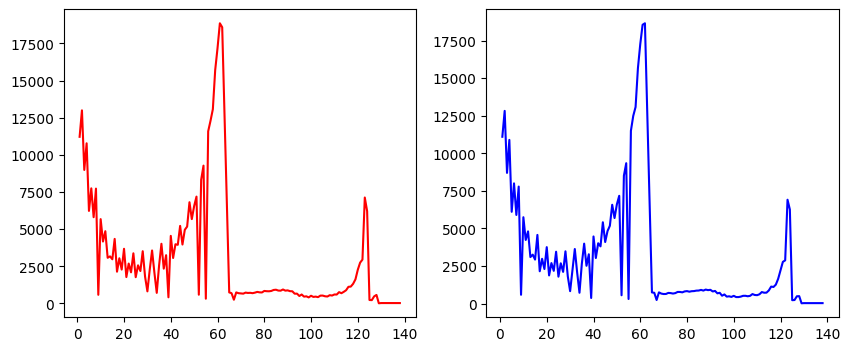

10976


In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('data_000637.txt')
print('Max row: ', len(data))
data
data_reduced = data[10001:1000000]
display(data_reduced)
m = data_reduced['BX_COUNTER'].max()
print('x = ', m+1)
data_reduced['times'] = data_reduced['TDC_MEAS']*25/30 + data_reduced['BX_COUNTER']*30 + data_reduced['ORBIT_CNT']*(m+1)*30
display(data_reduced)


elapse = (data_reduced['times'].max()- data_reduced['times'].min()) *10**(-9)
print('Elapse time= ', elapse, ' s')

data_reduced.loc[:,'HEAD']= np.random.randint(0, 2, size = (1000000-10001))
display(data_reduced)

head1 = data_reduced[data_reduced['HEAD']==1]
display(head1)

head0 = data_reduced[data_reduced['HEAD']==0]

fpga0 = head0['TDC_CHANNEL'].value_counts()
fpga0 = fpga0.sort_index(axis=0)
display(fpga0)
fpga1 = head1['TDC_CHANNEL'].value_counts()
fpga1 = fpga1.sort_index(axis=0)
display(fpga1)

fig , (ax0, ax1) = plt.subplots(1, 2, figsize= (10, 4))
ax0.plot(fpga0.index, fpga0.values, 'r')
ax1.plot(fpga1.index, fpga1.values, 'b')
plt.show()

head0_sort= head0.groupby('TDC_CHANNEL').count().sort_values(by='HEAD', ascending=False)
display(head0_sort)
#display(fpga0)
fpga0_clean = head0_sort.drop(head0_sort.index[[0,1,2]])
display(fpga0_clean)
fpga0_clean = fpga0_clean.sort_index()

head1_sort= head1.groupby('TDC_CHANNEL').count().sort_values(by='HEAD', ascending=False)
display(head1_sort)
#display(fpga0)
fpga1_clean = head1_sort.drop(head1_sort.index[[0,1,2]])
display(fpga1_clean)
fpga1_clean = fpga1_clean.sort_index()

fig , (ax0, ax1) = plt.subplots(1, 2, figsize= (10, 4))
ax0.plot(fpga0_clean.index, fpga0_clean['HEAD'], 'r')
ax1.plot(fpga1_clean.index, fpga1_clean['HEAD'], 'b')
plt.show()

unique = data[data['TDC_CHANNEL']==139]['ORBIT_CNT'].nunique()

print(unique)

1\. Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

2\. Find out the number of BX in a ORBIT (the value 'x').

3\. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) you read, or perform this check precisely by reading out the whole dataset.

4\. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).

5\. Replace the values (all 1) of the HEAD column randomly with 0 or 1.

6\. Create a new DataFrame that contains only the rows with HEAD=1.

7\. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

8\. Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

9\. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS
10001,1,0,47,3869200267,785,14
10002,1,0,63,3869200267,921,28
10003,1,0,64,3869200267,924,15
10004,1,0,7,3869200267,998,22
10005,1,0,8,3869200267,998,12
...,...,...,...,...,...,...
1310715,1,0,62,3869211171,762,14
1310716,1,1,4,3869211171,763,11
1310717,1,0,64,3869211171,764,0
1310718,1,0,139,3869211171,769,0


x=  3564
971545988.3125
980416253.3125


/tmp/ipykernel_921/1805979496.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_red['times'] = df_red['ORBIT_CNT']*3564*25 + df_red['BX_COUNTER']*25 + df_red['TDC_MEAS']*25/30
/tmp/ipykernel_921/1805979496.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_red['times'] = df_red['times']*10**(-9)
/tmp/ipykernel_921/1805979496.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in

TDC_CHANNEL
1      28201
2      32419
3      21777
4      26203
5      14875
       ...  
129       35
130       38
137       36
138       36
139    32181
Name: count, Length: 132, dtype: int64

TDC_CHANNEL
2      32419
139    32181
1      28201
4      26203
3      21777
       ...  
9         80
130       38
137       36
138       36
129       35
Name: count, Length: 132, dtype: int64


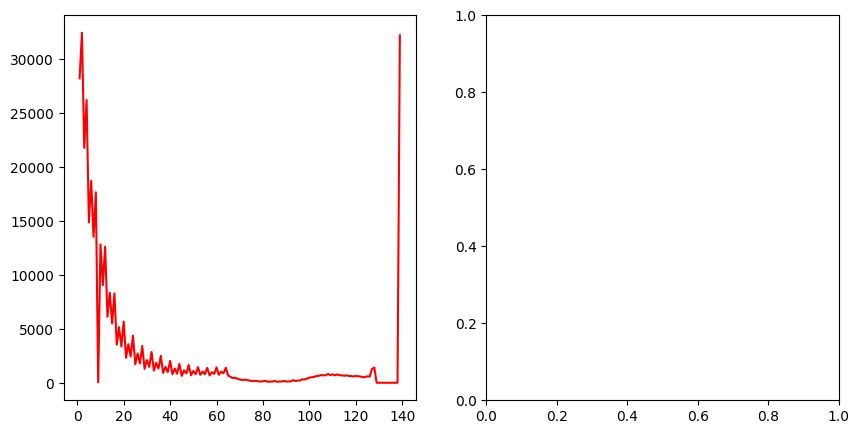

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('data_000637.txt')

df_red = df[10001:len(df)]
display(df_red)

print('x= ', df_red['BX_COUNTER'].max() +1)

df_red['times'] = df_red['ORBIT_CNT']*3564*25 + df_red['BX_COUNTER']*25 + df_red['TDC_MEAS']*25/30
print(df_red['times'].max()- df_red['times'].min()) #I have to do max - min!!

df['times'] = df['ORBIT_CNT']*3564*25 + df['BX_COUNTER']*25 + df['TDC_MEAS']*25/30
print(df['times'].max()- df['times'].min()) #I have to do max - min!!

df_red['times'] = df_red['times']*10**(-9)

df_red['HEAD'] = np.random.randint(0,2, (len(df_red),1))

head1 = df_red[df_red['HEAD']==1]
FPGA0 = df_red[df_red['FPGA']==0]
FPGA1 = df_red[df_red['FPGA']==1]

channel1 = FPGA1.value_counts('TDC_CHANNEL').sort_index()
channel1.columns=['ch', 'num']
display(channel1)
channel2 = FPGA1.value_counts('TDC_CHANNEL').sort_index()
print(channel2)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.plot(channel1.index, channel1.values, 'r')

1310721
The number of BX in a ORBIT is: 3564
Elaspse time of measurements (for the data I read):  0.9706675433125 s


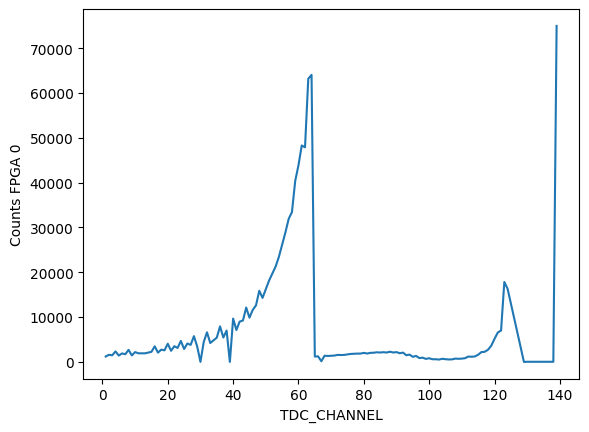

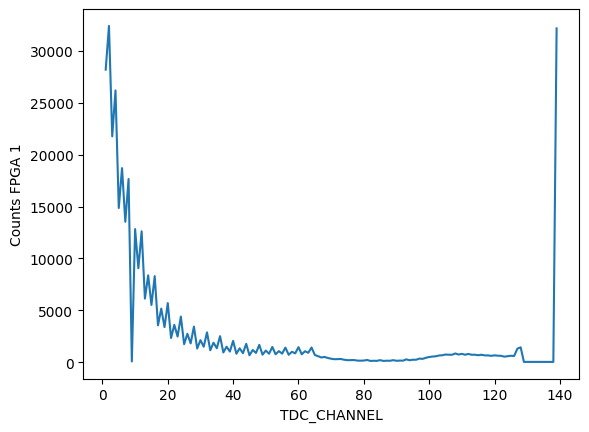

       HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_MEAS         times
11000     0     0           60  3869200277         284        20  3.447457e+14
11001     1     0          139  3869200277         288         0  3.447457e+14
11002     0     0           61  3869200277         286        11  3.447457e+14
11003     0     0           60  3869200277         290        25  3.447457e+14
11004     0     0           62  3869200277         283         8  3.447457e+14
11005     0     0           62  3869200277         289         3  3.447457e+14
11006     0     0           64  3869200277         292        24  3.447457e+14
11007     1     1          110  3869200277         986         8  3.447457e+14
11008     1     1            4  3869200277        1157        10  3.447457e+14
11009     0     0           61  3869200277        1163        12  3.447457e+14
     TDC_CHANNEL  counts
123          139   74964
58            64   64040
57            63   63179
     TDC_CHANNEL  counts
1     

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,times
11001,1,0,139,3869200277,288,0,3.447457e+14
11007,1,1,110,3869200277,986,8,3.447457e+14
11008,1,1,4,3869200277,1157,10,3.447457e+14
11010,1,1,5,3869200277,1157,12,3.447457e+14
11011,1,0,59,3869200277,1164,29,3.447457e+14
11013,1,0,62,3869200277,1160,20,3.447457e+14
11015,1,1,6,3869200277,1166,20,3.447457e+14
11017,1,1,3,3869200277,1165,22,3.447457e+14
11018,1,0,63,3869200277,1163,12,3.447457e+14
11022,1,0,58,3869200277,1353,13,3.447457e+14


In [8]:
import numpy as np
import pandas as pd
import numpy.random as npr
import matplotlib.pyplot as plt
npr.seed(123)

file_name= "/home/elena/data/data_000637.txt"
#file_name="~/data/data_000637.txt"
count_row=0
with open(file_name, 'r') as f:
    for row in f:
        count_row+=1
    print(count_row) #1310721, 11000<row<1310721
data=pd.read_csv(file_name) #to read the file

df=pd.DataFrame(data[11000:1310722]) #create the data frame

print ("The number of BX in a ORBIT is:", df['BX_COUNTER'].max(axis=0) + 1)
df['times'] = df['TDC_MEAS']*25/30+df['BX_COUNTER']*25+df['ORBIT_CNT']*3564*25 #new column with the absolute time in ns
print("Elaspse time of measurements (for the data I read): ", (df['times'].max(axis=0)-df['times'].min(axis=0))*10**(-9), "s") 
df.loc[:, 'HEAD'] = npr.randint(0,2, size = (len(df),1)) #replace 'HEAD' with random 0 or 1
df_new = pd.DataFrame(df[df['HEAD'] == 1])
FPGA_0 = pd.DataFrame(df[df['FPGA'] == 0])
counts_0=FPGA_0['TDC_CHANNEL'].value_counts()
counts_0=counts_0.sort_index()
counts_0.plot()
plt.xlabel('TDC_CHANNEL')
plt.ylabel('Counts FPGA 0')
plt.show()
FPGA_1 = pd.DataFrame(df[df['FPGA'] == 1])
counts_1=FPGA_1['TDC_CHANNEL'].value_counts()
counts_1=counts_1.sort_index()
counts_1.plot()
plt.xlabel('TDC_CHANNEL')
plt.ylabel('Counts FPGA 1')
plt.show()
print(df.head(10))

filtered_0 = FPGA_0.groupby('TDC_CHANNEL').size().reset_index(name="counts")
noise_0 = filtered_0.sort_values(by = 'counts', ascending = False).head(3)
print(noise_0)

filtered_1 = FPGA_1.groupby('TDC_CHANNEL').size().reset_index(name="counts")
noise_1 = filtered_1.sort_values(by = 'counts', ascending = False).head(3)
print(noise_1)

#n_unique_orbits = df["ORBIT_CNT"].nunique()
n_orbits_with_139 = (df[df["TDC_CHANNEL"] == 139]["ORBIT_CNT"].nunique()) #nunique counts the unique value for orbit_cnt

print(n_orbits_with_139)

df.tail(10)
df_new.head(10)

Number of rows for the entire file :
 1310721
DataFrame shape: (1300720, 6)
Head of Data frame with row from 10000 to  1310721  :
        HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_MEAS
10000     1     0           50  3869200267         776        22
10001     1     0           47  3869200267         785        14
10002     1     0           63  3869200267         921        28
10003     1     0           64  3869200267         924        15
10004     1     0            7  3869200267         998        22
x =  3564
The data tacking lasted:
 0.9626817425  seconds
Head of data frame with absolute time in ns :
 10000    3.447457e+14
10001    3.447457e+14
10002    3.447457e+14
10003    3.447457e+14
10004    3.447457e+14
Name: times, dtype: float64
Head of data frame wuth 'HEAD' set to 0 or 1 randomly :
 10000    0
10001    1
10002    1
10003    0
10004    1
Name: HEAD, dtype: int64
Head of data frame with 'HEAD' = 1 :
        HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_M

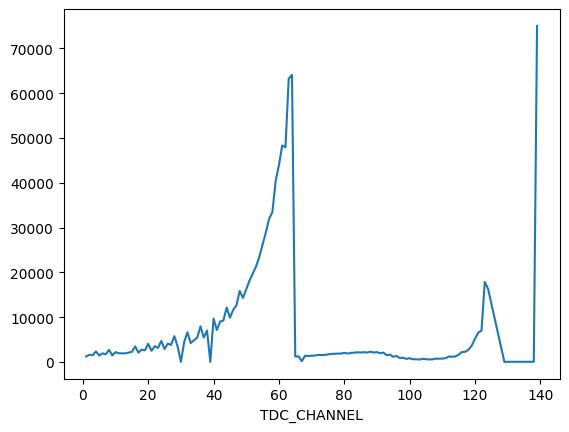

Head of data frame with 'FPGA' = 1 :
        HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_MEAS         times
10034     0     1           12  3869200267        1861        26  3.447457e+14
10035     1     1           14  3869200267        1861        19  3.447457e+14
10037     0     1            8  3869200267        2277         1  3.447457e+14
10038     1     1           10  3869200267        2283        12  3.447457e+14
10040     0     1           11  3869200267        2286        29  3.447457e+14


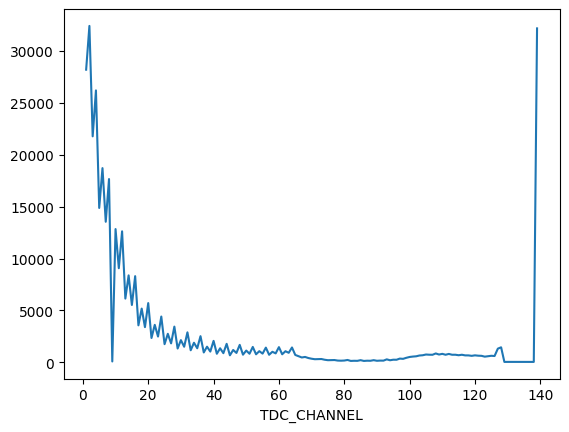

     TDC_CHANNEL  counts
0              1   29412
1              2   34011
2              3   23262
3              4   28544
4              5   16296
..           ...     ...
128          129      37
129          130      71
130          137      68
131          138      70
132          139  107199

[133 rows x 2 columns]
     TDC_CHANNEL  counts
132          139  107199
63            64   65529
62            63   64143
10876


In [28]:
import numpy as np
import pandas as pd
import numpy.random as npr
import matplotlib.pyplot as plt

file_name="/home/elena/data/data_000637.txt.1"
with open(file_name, 'r') as f:
    count_row = 0
    for row in f:
        count_row += 1
print("Number of rows for the entire file :\n", count_row)
data=pd.read_csv(file_name)

#Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. 
#Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.
df = pd.DataFrame(data[10000:count_row])
print(f"DataFrame shape: {df.shape}")
print("Head of Data frame with row from 10000 to ", count_row, " :\n", df.head())

#Find out the number of BX in a ORBIT (the value 'x')
print ( "x = ", df['BX_COUNTER'].max(axis=0)+1) 

#Find out how much the data taking lasted. 
#You can either make an estimate based on the fraction of the measurements (rows) 
#you read, or perform this check precisely by reading out the whole dataset.
df['times']=df['TDC_MEAS']*25/30+df['BX_COUNTER']*25+df['ORBIT_CNT']*3564*25
print("The data tacking lasted:\n", (df.iloc[-1]['times'] - df.iloc[10000]['times'])*10**(-9), " seconds")

#Create a new column with the absolute time in ns 
#(as a combination of the other three columns with timing information).
print("Head of data frame with absolute time in ns :\n", df['times'].head())

#Replace the values (all 1) of the HEAD column randomly with 0 or 1.
df['HEAD'] = np.random.randint(0, 2, size=len(df))
print("Head of data frame wuth 'HEAD' set to 0 or 1 randomly :\n", df['HEAD'].head())

#Create a new DataFrame that contains only the rows with HEAD=1.
df_mask = df[df['HEAD'] == 1]
df_head = pd.DataFrame(df_mask.dropna(how = 'any'))
print("Head of data frame with 'HEAD' = 1 :\n", df_head.head())

#Make two occupancy plots (one for each FPGA), 
#i.e. plot the number of counts per TDC channel
df_mask_0 = df[df['FPGA'] == 0]
fpga_0 = df_mask_0.dropna(how = 'any')
print("Head of data frame with 'FPGA' = 0 :\n", fpga_0.head())
count_0 = fpga_0['TDC_CHANNEL'].value_counts() #conta quante volte appare ogni TDC_CHANNEL
count_0 = count_0.sort_index()
count_0.plot()
plt.show()

df_mask_1 = df[df['FPGA'] == 1]
fpga_1 = df_mask_1.dropna(how = 'any')
print("Head of data frame with 'FPGA' = 1 :\n", fpga_1.head())
count_1 = fpga_1['TDC_CHANNEL'].value_counts() #conta quante volte appare ogni TDC_CHANNEL
count_1 = count_1.sort_index()
count_1.plot()
plt.show()

#Use the groupby method to find out the noisy channels, 
#i.e. the TDC channels with most counts (say the top 3)
filtered = df.groupby('TDC_CHANNEL').size().reset_index(name="counts")
print(filtered)
noise = filtered.sort_values(by = 'counts', ascending = False).head(3)
print(noise)

#Count the number of unique orbits. Count the number of unique orbits with at least one 
#measurement from TDC_CHANNEL=139
n_unique_orbits = df["ORBIT_CNT"].nunique()
n_orbits_with_139 = (df[df["TDC_CHANNEL"] == 139]["ORBIT_CNT"].nunique())

print(n_orbits_with_139)

In [7]:
N = data['BX_COUNTER'].max(axis=0)
print(N)

3563


In [8]:
print ("The number of BX in a orbit is ", N+1)

The number of BX in a orbit is  3564


In [9]:
orbit_max = data['ORBIT_CNT'].max(axis=0)
BX_max = N
TDC_max = data['TDC_MEAS'].max(axis=0)
print (orbit_max)
print (BX_max)
print(TDC_max)

3869209011
3563
29


In [10]:
orbit_min = data['ORBIT_CNT'].min(axis=0)
BX_min = data['BX_COUNTER'].min(axis=0)
TDC_min = data['TDC_MEAS'].min(axis=0)
print (orbit_min)
print (BX_min)
print(TDC_min)

3869200167
0
0


In [ ]:
max_ns = 